In [8]:
import ultraplot as uplt
# import matplotlib.pyplot as plt
import numpy as np

In [ ]:
import warnings

import healpy as hp
import numpy as np
import numpy.typing as npt
from astropy import units as u
from astropy.coordinates import SkyCoord
from astropy.time import Time

from rubin_scheduler.utils import DEFAULT_NSIDE, _hpid2_ra_dec

from rubin_scheduler.scheduler.utils.sky_area import CurrentAreaMap
from rubin_scheduler.scheduler.utils.footprints import (
    Footprint,
    StepSlopes,
    Footprints,
)

# survey start from commit 5e34aa5102d3d44fc03c2a74934338fc2ba2d1b9
# on https://github.com/lsst-sims/sims_featureScheduler_runs5.3
SURVEY_START_MJD = Time("2026-06-15T12:00:00").mjd

YEAR = 365.25

def _is_in_ra_range(ra, low, high):
    _low = low % (2.0 * np.pi)
    _high = high % (2.0 * np.pi)
    if _low <= _high:
        return (ra >= _low) & (ra <= _high)
    else:
        return (ra >= _low) | (ra <= _high)


def slice_quad_galactic_cut(target_map, nslice=2, wfd_indx=None, ra_range=None):
    """
    Helper function for generating rolling footprints

    Parameters
    ----------
    target_map : dict of HEALpix maps
        The final desired footprint as HEALpix maps. Keys are band names
    nslice : `int`
        The number of slices to make, can be 2 or 3.
    wfd_indx : array of ints
        The indices of target_map that should be used for rolling.
        If None, assumes the rolling area should be where target_map['r'] == 1.
    ra_range : tuple of floats, optional
        If not None, then the indices are restricted to the given RA range
        in radians.
    """
    nside = hp.npix2nside(target_map["r"].size)
    ra, dec = _hpid2_ra_dec(nside, np.arange(hp.nside2npix(nside)))

    coord = SkyCoord(ra=ra * u.rad, dec=dec * u.rad)
    _, gal_lat = coord.galactic.l.deg, coord.galactic.b.deg

    indx_north = np.intersect1d(np.where(gal_lat >= 0)[0], wfd_indx)
    indx_south = np.intersect1d(np.where(gal_lat < 0)[0], wfd_indx)

    splits_north = slice_wfd_area_quad(target_map, nslice=nslice, wfd_indx=indx_north)
    splits_south = slice_wfd_area_quad(target_map, nslice=nslice, wfd_indx=indx_south)

    slice_indx = []
    for j in np.arange(nslice):
        indx_temp = []
        for i in np.arange(j + 1, nslice * 2 + 1, nslice):
            indx_temp += indx_north[splits_north[i - 1] : splits_north[i]].tolist()
            indx_temp += indx_south[splits_south[i - 1] : splits_south[i]].tolist()
        slice_indx.append(indx_temp)

    if ra_range is not None:
        ra_indx = np.where(_is_in_ra_range(ra, *ra_range))[0]
        for j in range(nslice):
            slice_indx[j] = np.intersect1d(ra_indx, slice_indx[j])

    return slice_indx


def slice_wfd_area_quad(target_map, nslice=2, wfd_indx=None):
    """
    Divide a healpix map in an intelligent way

    Parameters
    ----------
    target_map : dict of HEALpix arrays
        The input map to slice
    nslice : int
        The number of slices to divide the sky into (gets doubled).
    wfd_indx : array of int
        The indices of the healpix map to consider as part of the WFD area
        that will be split.
        If set to None, the pixels where target_map['r'] == 1 are
        considered as WFD.
    """
    nslice2 = nslice * 2

    wfd = target_map["r"] * 0
    if wfd_indx is None:
        wfd_indices = np.where(target_map["r"] == 1)[0]
    else:
        wfd_indices = wfd_indx
    wfd[wfd_indices] = 1
    wfd_accum = np.cumsum(wfd)
    split_wfd_indices = np.floor(np.max(wfd_accum) / nslice2 * (np.arange(nslice2) + 1)).astype(int)
    split_wfd_indices = split_wfd_indices.tolist()
    split_wfd_indices = [0] + split_wfd_indices

    return split_wfd_indices


def slice_wfd_indx(target_map, nslice=2, wfd_indx=None):
    """
    simple map split
    """

    wfd = target_map["r"] * 0
    if wfd_indx is None:
        wfd_indx = np.where(target_map["r"] == 1)[0]
    wfd[wfd_indx] = 1
    wfd_accum = np.cumsum(wfd)
    split_wfd_indices = np.floor(np.max(wfd_accum) / nslice * (np.arange(nslice) + 1)).astype(int)
    split_wfd_indices = split_wfd_indices.tolist()
    split_wfd_indices = [0] + split_wfd_indices

    return split_wfd_indices


# default function from commit e6d604718bcf3253434c8ddfee0250d9d09b5c8e
# on rubin_scheduler
def make_rolling_footprints(
    *,
    mjd_start,
    strategy,
    fp_hp=None,
    nside=DEFAULT_NSIDE,
    wfd_indx=None,
    rolling_start_shift=0,
):
    """
    Generate rolling footprints

    Parameters
    ----------
    fp_hp : dict-like
        A dict with band name keys and HEALpix map values.
        Default None will load CurrentAreaMap. Assumes
        WFD is where r-band is 1.
    mjd_start : `float`
        The starting date of the survey.
    wfd_indx : array of ints
        The indices of the HEALpix map that are to be included in the rolling.

    Returns
    -------
    Footprints object
    """

    from rubin_scheduler.site_models import Almanac

    # Use the Almanac to find the position of the sun at the start of survey
    almanac = Almanac(mjd_start=mjd_start)
    sun_moon_info = almanac.get_sun_moon_positions(mjd_start)
    sun_ra_start = sun_moon_info["sun_RA"].copy()

    if rolling_start_shift != 0:
        from rubin_scheduler.site_models import Almanac

        # Use the Almanac to find the position of the sun at the start of survey
        almanac = Almanac(mjd_start=mjd_start + rolling_start_shift / 2.0 / np.pi * YEAR)
        sun_moon_info = almanac.get_sun_moon_positions(mjd_start + rolling_start_shift / 2.0 / np.pi * YEAR)
        shifted_sun_ra_start = sun_moon_info["sun_RA"].copy()
    else:
        shifted_sun_ra_start = sun_ra_start

    if fp_hp is None:
        sky = CurrentAreaMap(nside=nside)
        footprints, labels = sky.return_maps()
        fp_hp = {}
        for key in footprints.dtype.names:
            fp_hp[key] = footprints[key]

    hp_footprints = fp_hp

    nslice = 2
    scale = 0.9
    D = 1.0 - scale
    U = nslice - D * (nslice - 1)

    dvals = {
        1: "1",
        D: "D",
        U: "U",
    }
    inv_dvals = {v: k for k, v in dvals.items()}

    assert strategy is not None
    print("using strategy:", strategy)

    if strategy == "uniform-5.3":
        str_all_slopes = [
            "1 1 D U 1 D U 1 D U 1 1 1 1 1 1 1",
            "1 1 U D 1 U D 1 U D 1 1 1 1 1 1 1",
            "1 1 1 U D 1 U D 1 U D 1 1 1 1 1 1",
            "1 1 1 D U 1 D U 1 D U 1 1 1 1 1 1",
        ]
    elif strategy == "uniform":
        str_all_slopes = [
            "1 1 U D 1 U D 1 U D 1 1 1 1 1 1 1",
            "1 1 D U 1 D U 1 D U 1 1 1 1 1 1 1",
            "1 1 1 U D 1 U D 1 U D 1 1 1 1 1 1",
            "1 1 1 D U 1 D U 1 D U 1 1 1 1 1 1",
        ]
        # str_all_slopes = [
        #     "1 1 U D 1 U D 1 U D 1 1 1 1 1 1 1",
        #     "1 1 D U 1 D U 1 D U 1 1 1 1 1 1 1",
        #     "1 1 1 D U 1 D U 1 D U 1 1 1 1 1 1",
        #     "1 1 1 U D 1 U D 1 U D 1 1 1 1 1 1",
        # ]
    else:
        raise RuntimeError(
            "survey strategy "
            + strategy
            + " was not found!"
        )

    all_slopes = []
    for sstr in str_all_slopes:
        all_slopes.append(
            [inv_dvals[s] for s in sstr.split(" ")]
        )

    abc = ["a", "b", "c", "d", "e", "f", "g", "h"]
    slice_names = ["slice %s" % abc[i] for i in range(nslice)]
    for i, s in enumerate(all_slopes):
        if i >= nslice:
            sname = slice_names[i - nslice] + " w/ ra - sun_ra in [90, 270]"
        else:
            sname = slice_names[i] + " w/ ra - sun_ra in [270, 90]"
        print(sname + ": " + " ".join([dvals[x] for x in s]))

    fp_non_wfd = Footprint(mjd_start, sun_ra_start=sun_ra_start, nside=nside)
    rolling_footprints = []
    for i in range(len(all_slopes)):
        step_func = StepSlopes(rise=all_slopes[i])
        rolling_footprints.append(
            Footprint(
                mjd_start + rolling_start_shift / 2.0 / np.pi * YEAR,
                sun_ra_start=shifted_sun_ra_start,
                step_func=step_func,
                nside=nside,
            )
        )

    wfd = hp_footprints["r"] * 0
    if wfd_indx is None:
        wfd_indx = np.where(hp_footprints["r"] == 1)[0]

    wfd[wfd_indx] = 1
    non_wfd_indx = np.where(wfd == 0)[0]

    split_wfd_indices = slice_quad_galactic_cut(
        hp_footprints,
        nslice=nslice,
        wfd_indx=wfd_indx,
        ra_range=(shifted_sun_ra_start + 1.5 * np.pi, shifted_sun_ra_start + np.pi / 2),
    )

    split_wfd_indices_delayed = slice_quad_galactic_cut(
        hp_footprints,
        nslice=nslice,
        wfd_indx=wfd_indx,
        ra_range=(shifted_sun_ra_start + np.pi / 2, shifted_sun_ra_start + 1.5 * np.pi),
    )

    for key in hp_footprints:
        temp = hp_footprints[key] + 0
        temp[wfd_indx] = 0
        fp_non_wfd.set_footprint(key, temp)

        for i in range(nslice):
            # make a copy of the current band
            temp = hp_footprints[key] + 0
            # Set the non-rolling area to zero
            temp[non_wfd_indx] = 0

            indx = split_wfd_indices[i]
            # invert the indices
            ze = temp * 0
            ze[indx] = 1
            temp = temp * ze
            rolling_footprints[i].set_footprint(key, temp)

            for _i in range(nslice, nslice * 2):
                # make a copy of the current band
                temp = hp_footprints[key] + 0
                # Set the non-rolling area to zero
                temp[non_wfd_indx] = 0

                indx = split_wfd_indices_delayed[_i - nslice]
                # invert the indices
                ze = temp * 0
                ze[indx] = 1
                temp = temp * ze
                rolling_footprints[_i].set_footprint(key, temp)

    result = Footprints([fp_non_wfd] + rolling_footprints)
    return result

/Users/beckermr/mambaforge/envs/rubin-sims-2026-05-06/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def get_desi_stripes():
    # code for DESI stripes from Anand Raichoor
    names = np.array([
        "NGC-1", "NGC-2", "NGC-3", "NGC-4", "NGC-5", "NGC-6", "NGC-7", "NGC-8", "NGC-9",
        "SGC-1", "SGC-2", "SGC-3", "SGC-4", "SGC-5", "SGC-6", "SGC-7", "SGC-8", "SGC-9",
    ])
    surveys = np.array([
        "POLU+IBIS", "POLU+IBIS", "POLU+IBIS", "POLU+IBIS", "Niji+VST", "Niji+VST", "POLU+IBIS", "POLU+IBIS", "POLU+IBIS",
        "Niji+VST", "Niji+VST", "POLU+IBIS", "POLU+IBIS", "POLU+IBIS", "POLU+IBIS", "POLU+IBIS", "POLU+IBIS", "POLU+IBIS",
    ])
    yrs = np.array([
        4, 3, 2, 2, 4, 3, 1, 1, 5,
        4, 3, 3, 2, 2, 1, 1, 4, 5,
    ])
    ramins = np.array([
        121.01, 122.33, 123.69, 125.11, 126.60, 128.16, 129.81, 131.56, 133.43,
        315.57, 313.82, 312.19, 310.66, 309.21, 307.84, 306.53, 305.29, 304.10,
    ])
    ramaxs = np.array([
        255.71, 254.40, 253.00, 251.52, 249.93, 228.30, 225.58, 222.41, 218.59,
        44.37, 47.15, 49.56, 51.67, 53.53, 55.18, 56.64, 57.93, 59.06,
    ])
    decmins = np.array([
        11.375, 8.875, 5.875, 3.125, 0.375, -2.375, -5.375, -8.125, -10.875,
        1.625, -1.375,  -4.125, -6.875, -9.625, -12.375, -15.375, -18.125, -20.875,
    ])
    decmaxs = np.array([
        15.125, 12.375, 9.375, 6.625, 3.875, 1.125, -1.625, -4.625, -7.375,
        5.125, 2.375, -0.625, -3.375, -6.125, -8.875, -11.625, -14.625, -17.375,
    ])
    return dict(names=names, surveys=surveys, yrs=yrs, ramins=ramins, ramaxs=ramaxs, decmins=decmins, decmaxs=decmaxs)


def plot_map_at_mjd(ax, footprint, mjd, band="i", npix=200, cmap=None, vmin=0, vmax=11, index_to_plot=None, level_factor=2):
    import skyproj.hpx_utils

    imap = footprint(mjd, norm=False)[band]
    if index_to_plot is not None:
        all_index = np.arange(imap.shape[0])
        non_index_to_plot = np.setdiff1d(all_index, index_to_plot)
        imap[non_index_to_plot] = np.nan

    lon, lat, xymap = skyproj.hpx_utils.hpxmap_to_xy(
        imap,
        [0, 360],
        [-90, 90],
        xsize=npix,
    )
    vmax = int(np.ceil(vmax) + 1)

    m = ax.pcolormesh(
        lon, lat, xymap,
        cmap=cmap,
        discrete=False,
        vmin=vmin, vmax=vmax,
        levels=np.linspace(vmin, vmax, vmax * level_factor + 1) - 0.5 / level_factor,
    )

    desi = get_desi_stripes()

    cmap = uplt.Colormap('colorblind', samples=5)

    cleg = {}
    for i in range(len(desi["names"])):
        cind = int(desi["yrs"][i]) - 1
        ramin, ramax = desi["ramins"][i], desi["ramaxs"][i]
        if ramin > ramax:
            ramin = ramin - 360.0
            # ramin, ramax = ramax, ramin
        cleg[cind] = ax.plot(
            [ramin, ramax],
            [desi["decmins"][i], desi["decmins"][i]],
            color=cmap(cind % 5),
            label=f"DESI {cind+1}",
        )
        ax.plot(
            [ramin, ramax],
            [desi["decmaxs"][i], desi["decmaxs"][i]],
            color=cmap(cind % 5),
            linestyle="dashed",
        )

    ax.invert_xaxis()
    ax.colorbar(m, ticks=np.linspace(vmin, vmax, vmax * level_factor + 1), minorticks=[])
    ax.legend([cleg[i] for i in range(5)], loc="t", ncols=5, frameon=False)

In [3]:
# code from commit 5e34aa5102d3d44fc03c2a74934338fc2ba2d1b9
# on https://github.com/lsst-sims/sims_featureScheduler_runs5.3
nside = 32
survey_start_mjd = SURVEY_START_MJD

# Parameters for rolling cadence footprint definition

# Generate footprint over the sky
sky = CurrentAreaMap(nside=nside)
footprints_hp_array, labels = sky.return_maps()
# Identify pixels for rolling
roll_indx = np.where((labels == "lowdust") | (labels == "virgo"))[0]
roll_footprint = footprints_hp_array["r"] * 0
roll_footprint[roll_indx] = 1

footprints_hp = {}
for key in footprints_hp_array.dtype.names:
    footprints_hp[key] = footprints_hp_array[key]


rolling_start_shift = 0  # fractions of a year

# Define the rolling footprint
# footprints = make_rolling_footprints(
#     fp_hp=footprints_hp,
#     mjd_start=survey_start_mjd,
#     nside=nside,
#     wfd_indx=roll_indx,
#     strategy="uniform-5.3",
# )
special_footprints = make_rolling_footprints(
    fp_hp=footprints_hp,
    mjd_start=survey_start_mjd,
    nside=nside,
    wfd_indx=roll_indx,
    strategy="uniform",
    rolling_start_shift=rolling_start_shift * 2.0 * np.pi,
)

using strategy: uniform
slice a w/ ra - sun_ra in [270, 90]: 1 1 U D 1 U D 1 U D 1 1 1 1 1 1 1
slice b w/ ra - sun_ra in [270, 90]: 1 1 D U 1 D U 1 D U 1 1 1 1 1 1 1
slice a w/ ra - sun_ra in [90, 270]: 1 1 1 U D 1 U D 1 U D 1 1 1 1 1 1
slice b w/ ra - sun_ra in [90, 270]: 1 1 1 D U 1 D U 1 D U 1 1 1 1 1 1
[ 549 1099 1648 2198]
[ 770 1540 2310 3080]
[ 549 1099 1648 2198]
[ 770 1540 2310 3080]


/var/folders/41/j8jxg9p94cd_04wlhd_zn0lr0000gn/T/ipykernel_3253/922235901.py:51: UltraPlotWarning: Ignoring unused keyword args(s): {'levels': array([-0.25,  0.25,  0.75,  1.25,  1.75,  2.25,  2.75,  3.25,  3.75,
        4.25,  4.75,  5.25,  5.75])}
  m = ax.pcolormesh(


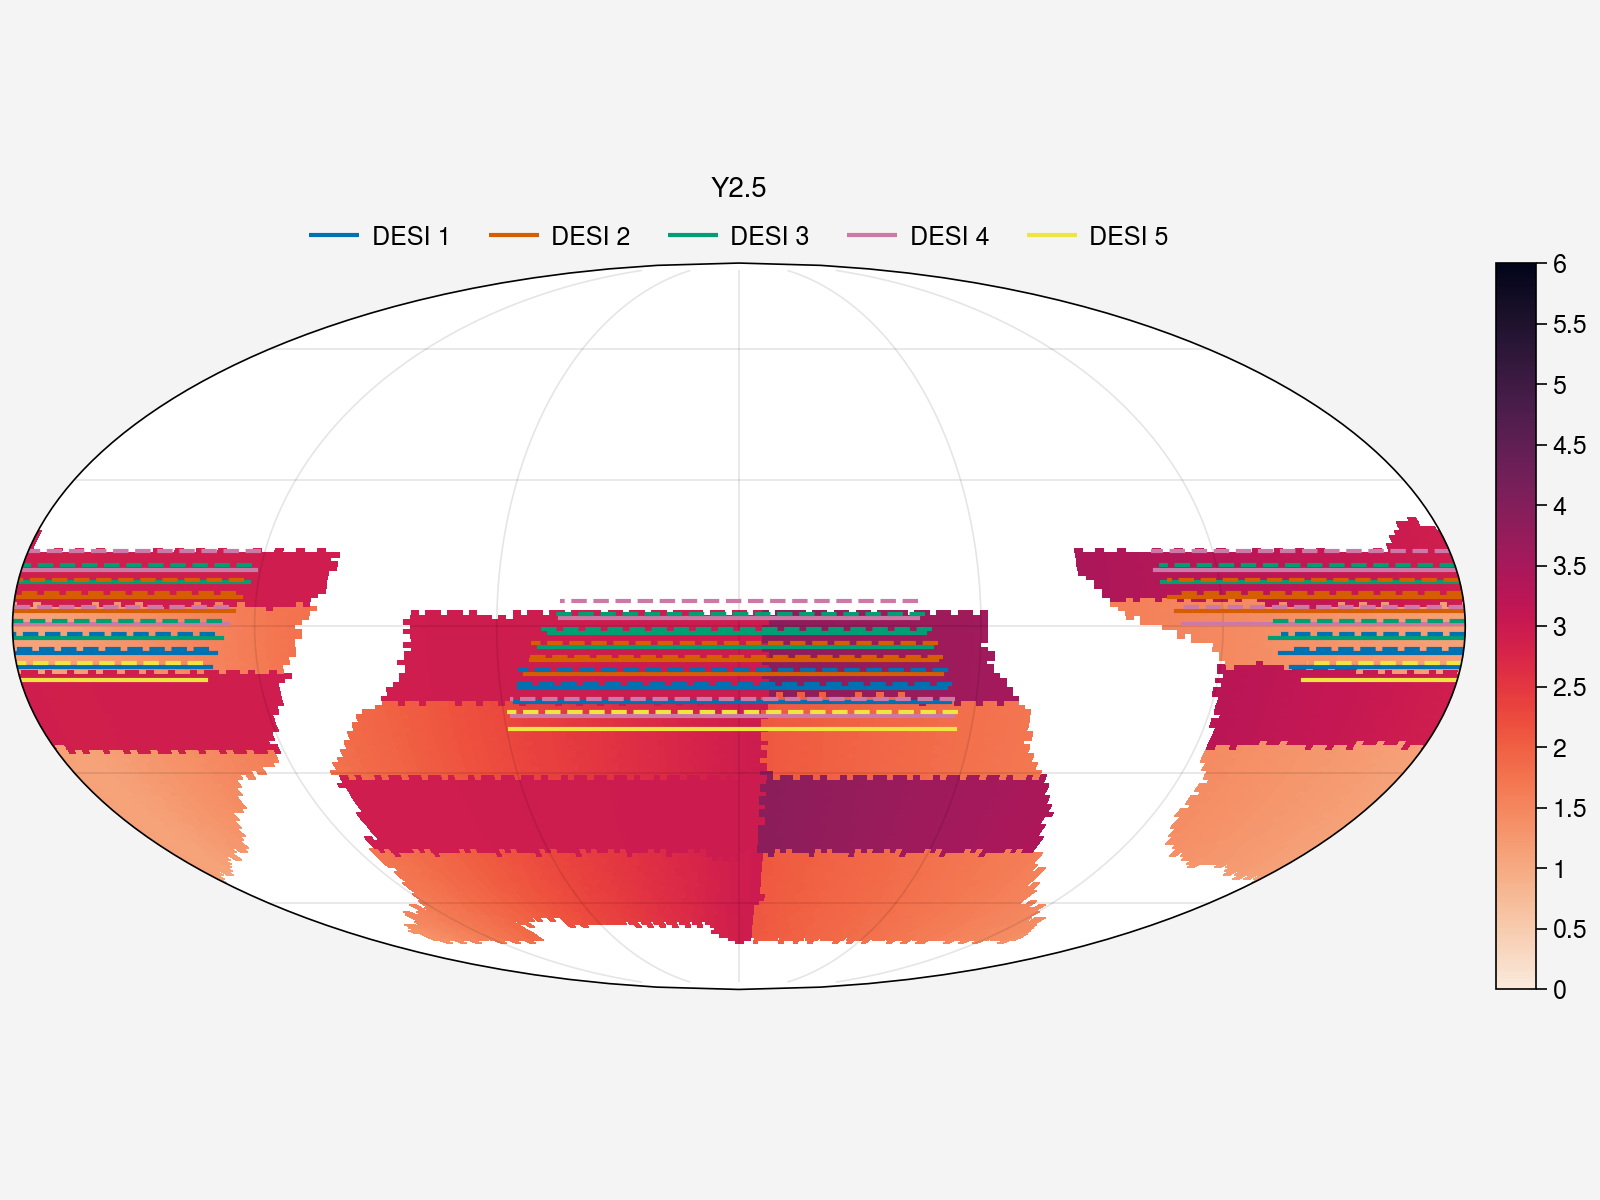

In [12]:
fig, axs = uplt.subplots(nrows=1, ncols=1, figsize=(8, 6), proj="moll")
for i in range(1):
    year = 2.5

    # plot_map_at_mjd(axs[i, 0], footprints, survey_start_mjd + year * YEAR, cmap="gray_r")
    # if i == 0:
    #     axs[i, 0].format(title=f"uniform rolling\nY{year}")
    # else:
    #     axs[i, 0].format(title=f"Y{year}")

    plot_map_at_mjd(
        axs[i, 0],
        special_footprints,
        survey_start_mjd + year * YEAR,
        cmap="rocket_r",
        index_to_plot=roll_indx,
        vmax=5,
    )
    axs[i, 0].format(title=f"Y{year}")

In [ ]:
vmax = 1.25
vmax = int(np.ceil(vmax) + 1)
np.linspace(0, vmax, vmax * 2 + 1) - 0.25

In [ ]:
vmin = 0
vmax = 11
np.linspace(vmin, vmax, vmax * 2 + 1) - 0.25